# Tier 3: XLS-R-300M Fine-tuning for Slavic Language Identification

## What this notebook does
- Loads pre-cached raw 16 kHz waveforms from Drive / Kaggle Dataset
- Fine-tunes `facebook/wav2vec2-xls-r-300m` with a linear classification head
- **Freezes** the CNN feature encoder and transformer layers 1-18
- **Unfreezes** the last 6 transformer layers (19-24) + final layer norm
- Trains with CrossEntropy loss
- Evaluates per-language accuracy, confusion matrix, t-SNE embeddings
- Compares against Tier 1 (MelCNN) and Tier 2 (CNN+BiLSTM) baselines

## Architecture
```
Raw waveform  (48 000 samples = 3 s @ 16 kHz)
  -> Wav2Vec2 CNN feature encoder    [FROZEN]
  -> Transformer layers  1-18        [FROZEN]
  -> Transformer layers 19-24        [UNFROZEN -- last 6]
  -> Final layer norm                [UNFROZEN]
  -> Mean pool over time             -> (B, 1024)
  -> Dropout(0.1) + Linear(1024, 8) -> (B, 8)
```

## Languages
Belarusian, Bulgarian, Czech, Macedonian, Polish, Russian, Serbian, Ukrainian

In [1]:
!pip install -q datasets torchaudio librosa scikit-learn matplotlib seaborn torch transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 81.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoFeatureExtractor, Wav2Vec2Model
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
from huggingface_hub import login

try:
    from google.colab import userdata
    login(token=userdata.get("HF_TOKEN"))
except (ImportError, Exception):
    from kaggle_secrets import UserSecretsClient
    login(token=UserSecretsClient().get_secret("HF_TOKEN"))

In [4]:
REPO_ID = "su-fmi-pytorch-slavic/slavic-languages-dataset"
MODEL_NAME = "facebook/wav2vec2-xls-r-300m"

SAMPLE_RATE = 16_000
CHUNK_SAMPLES = 48_000   # 3 seconds * 16 000 Hz

LANGUAGES = ["be", "bg", "cs", "mk", "pl", "ru", "sr", "uk"]
LANG2ID = {lang: i for i, lang in enumerate(sorted(LANGUAGES))}
ID2LANG = {v: k for k, v in LANG2ID.items()}

In [5]:
# Auto-detect environment (works on both Colab and Kaggle without changes)
# NOTE: Tier 3 uses a RAW WAVEFORM cache (not the mel cache from Tiers 1/2).
#       First run streams from HuggingFace and saves ~3-5 GB to Drive/Kaggle working.
#       Add the resulting NPZ files as a Kaggle Dataset called "slavic-lid-raw"
#       for instant loads on future sessions.
IN_KAGGLE = os.path.exists("/kaggle/working")

if IN_KAGGLE:
    CKPT_DIR = "/kaggle/working/tier3"
    SAVE_NPZ_TRAIN = "/kaggle/working/train_raw_f16.npz"
    SAVE_NPZ_TEST  = "/kaggle/working/test_raw_f16.npz"
    _inp_train = "/kaggle/input/datasets/ramihennawi/slavic-lid-raw/train_raw_f16.npz"
    _inp_test  = "/kaggle/input/datasets/ramihennawi/slavic-lid-raw/test_raw_f16.npz"
    CACHE_NPZ_TRAIN = _inp_train if os.path.exists(_inp_train) else SAVE_NPZ_TRAIN
    CACHE_NPZ_TEST = _inp_test  if os.path.exists(_inp_test)  else SAVE_NPZ_TEST
    # Tier 1/2 checkpoint paths (for comparison cell)
    T1_CKPT = "/kaggle/input/datasets/ramihennawi/slavic-lid-cache/mel_cnn_final.pt"
    T2_CKPT = "/kaggle/input/datasets/ramihennawi/slavic-lid-cache/cnn_bilstm_final.pt"
    print("Environment: Kaggle")
else:
    from google.colab import drive
    drive.mount("/content/drive")
    _BASE = "/content/drive/MyDrive/slavic_lid"
    CKPT_DIR = f"{_BASE}/tier3"
    CACHE_NPZ_TRAIN = f"{_BASE}/train_raw_f16.npz"
    CACHE_NPZ_TEST = f"{_BASE}/test_raw_f16.npz"
    SAVE_NPZ_TRAIN = CACHE_NPZ_TRAIN
    SAVE_NPZ_TEST = CACHE_NPZ_TEST
    T1_CKPT = f"{_BASE}/tier1/mel_cnn_final.pt"
    T2_CKPT = f"{_BASE}/tier2/cnn_bilstm_final.pt"
    print("Environment: Google Colab")

os.makedirs(CKPT_DIR, exist_ok=True)

if os.path.exists(CACHE_NPZ_TRAIN) and os.path.exists(CACHE_NPZ_TEST):
    print("Raw waveform cache found -- loading...")
    d = np.load(CACHE_NPZ_TRAIN); X_train, y_train = d["X"], d["y"]
    d = np.load(CACHE_NPZ_TEST);  X_test,  y_test  = d["X"], d["y"]
    print(f"  Train: {X_train.shape}  ({X_train.nbytes / 1e9:.2f} GB)")
    print(f"  Test:  {X_test.shape}  ({X_test.nbytes / 1e9:.2f} GB)")
    print("Ready!")
else:
    print("No raw cache found -- will stream-extract in the next cell.")
    X_train = y_train = X_test = y_test = None

Environment: Kaggle
Raw waveform cache found -- loading...
  Train: (80000, 48000)  (7.68 GB)
  Test:  (107439, 48000)  (10.31 GB)
Ready!


In [6]:
if IN_KAGGLE:
    print("Running on Kaggle -- no Drive mount needed.")
else:
    assert os.path.exists("/content/drive/MyDrive"), "Drive not mounted!"
    print("Drive confirmed mounted")

Running on Kaggle -- no Drive mount needed.


## Data Cache: Raw Waveforms

Unlike Tiers 1 and 2, XLS-R processes **raw 16 kHz waveforms** directly
(its internal CNN feature encoder replaces the mel spectrogram step).
We cache the raw audio as float16 to avoid re-downloading on each session.

In [7]:
import gc

if X_train is None:
    print("Streaming raw waveforms from HuggingFace...")
    print("This saves ~3-6 GB to your Drive/working dir (runs once only).")
    raw_stream = load_dataset(REPO_ID, streaming=True)

    def _stream_raw(split_iter, desc):
        X_list, y_list = [], []
        for ex in tqdm(split_iter, desc=desc):
            wav = np.array(ex["audio"]["array"], dtype=np.float32)
            # Pad or crop to exactly CHUNK_SAMPLES
            if len(wav) < CHUNK_SAMPLES:
                wav = np.pad(wav, (0, CHUNK_SAMPLES - len(wav)))
            else:
                wav = wav[:CHUNK_SAMPLES]
            X_list.append(wav.astype(np.float16))
            y_list.append(int(ex["label"]))
        return np.stack(X_list), np.array(y_list, dtype=np.int32)

    print("Extracting train waveforms...")
    X_train, y_train = _stream_raw(raw_stream["train"], "Train")
    np.savez_compressed(SAVE_NPZ_TRAIN, X=X_train, y=y_train)
    print(f"  Saved {os.path.getsize(SAVE_NPZ_TRAIN)/1e9:.2f} GB -> {SAVE_NPZ_TRAIN}")

    print("Extracting test waveforms...")
    X_test, y_test = _stream_raw(raw_stream["test"], "Test")
    np.savez_compressed(SAVE_NPZ_TEST, X=X_test, y=y_test)
    print(f"  Saved {os.path.getsize(SAVE_NPZ_TEST)/1e9:.2f} GB -> {SAVE_NPZ_TEST}")

    del raw_stream; gc.collect()

    if IN_KAGGLE:
        print("\nFiles saved to /kaggle/working/.")
        print("After this session: Data tab -> output NPZ files -> 'New Dataset'")
        print("Name it 'slavic-lid-raw' and attach it next session for instant loads!")
    else:
        print("\nSaved to Drive. Future restarts load in seconds.")
else:
    print("Cache already loaded -- nothing to do here.")

print(f"\nTrain: {len(y_train):,} samples | Test: {len(y_test):,} samples")

Cache already loaded -- nothing to do here.

Train: 80,000 samples | Test: 107,439 samples


## Feature Extractor

The `Wav2Vec2FeatureExtractor` normalizes each waveform to zero mean / unit variance. This is the only preprocessing step - no mel spectrograms.

In [8]:
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)
print(f"Feature extractor sampling rate: {feature_extractor.sampling_rate}")
print(f"Normalization: {feature_extractor.do_normalize}")

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Feature extractor sampling rate: 16000
Normalization: True


In [9]:
class SlavicRawDataset(Dataset):
    # Loads float16 raw waveforms, normalizes via Wav2Vec2FeatureExtractor
    def __init__(self, X: np.ndarray, y: np.ndarray, feature_extractor):
        self.X  = X   # (N, 48000) float16
        self.y  = y
        self.fe = feature_extractor

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        wav    = self.X[idx].astype(np.float32)
        inputs = self.fe(wav, sampling_rate=SAMPLE_RATE,
                         return_tensors='pt', padding=False)
        return inputs.input_values.squeeze(0), int(self.y[idx])


## DataLoaders

In [10]:
BATCH_SIZE = 8   # XLS-R is large; 8 fits comfortably in T4 (16 GB VRAM)

rng = np.random.default_rng(42)
small_idx = rng.choice(len(y_test), size=min(4_000, len(y_test)), replace=False)

train_dataset = SlavicRawDataset(X_train, y_train, feature_extractor)
test_small_dataset = SlavicRawDataset(X_test[small_idx], y_test[small_idx], feature_extractor)
test_full_dataset = SlavicRawDataset(X_test, y_test, feature_extractor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_small_loader = DataLoader(test_small_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_full_loader = DataLoader(test_full_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset):,} samples")
print(f"Test small: {len(test_small_dataset):,} samples (used during training)")
print(f"Test full: {len(test_full_dataset):,} samples (used for final eval)")

Train: 80,000 samples
Test small: 4,000 samples (used during training)
Test full: 107,439 samples (used for final eval)


## Model: XLS-R-300M + Classification Head

XLS-R-300M has 24 transformer layers. We freeze all but the last 6,
which gives us a good trade-off between generalization (pretrained features)
and task adaptation (Slavic language-specific fine-tuning).

| Component | Trainable |
|---|---|
| CNN feature encoder | Frozen |
| Transformer layers 1-18 | Frozen |
| Transformer layers 19-24 (last 6) | **Unfrozen** |
| Final layer norm | **Unfrozen** |
| Classification head Linear(1024, 8) | **Unfrozen** |

In [11]:
class XLSR_LID(nn.Module):
    def __init__(self, n_classes: int = 8, model_name: str = MODEL_NAME,
                 unfreeze_last_n: int = 6):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(model_name)

        # Step 1: freeze everything
        for param in self.wav2vec2.parameters():
            param.requires_grad = False

        # Step 2: unfreeze last `unfreeze_last_n` transformer layers
        total_layers = len(self.wav2vec2.encoder.layers)
        for layer in self.wav2vec2.encoder.layers[-unfreeze_last_n:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Step 3: unfreeze the final layer norm
        for param in self.wav2vec2.encoder.layer_norm.parameters():
            param.requires_grad = True

        hidden_size = self.wav2vec2.config.hidden_size  # 1024 for XLS-R-300M
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size, n_classes)

        frozen = sum(p.numel() for p in self.wav2vec2.parameters() if not p.requires_grad)
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total layers: {total_layers}, unfreezing last {unfreeze_last_n}")
        print(f"Frozen parameters:    {frozen:,}")
        print(f"Trainable parameters: {trainable:,}")

    def _pool(self, hidden_states: torch.Tensor) -> torch.Tensor:
        return hidden_states.mean(dim=1)  # mean pooling over time

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        outputs = self.wav2vec2(input_values)
        pooled = self._pool(outputs.last_hidden_state)
        return self.classifier(self.dropout(pooled))

    def get_embeddings(self, input_values: torch.Tensor) -> torch.Tensor:
        outputs = self.wav2vec2(input_values)
        return self._pool(outputs.last_hidden_state)

In [12]:
model = XLSR_LID(n_classes=8).to(DEVICE)

dummy = torch.zeros(2, CHUNK_SAMPLES).to(DEVICE)
print(f"Output shape: {model(dummy).shape}")
print(f"Embedding shape: {model.get_embeddings(dummy).shape}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total layers: 24, unfreezing last 6
Frozen parameters:    239,859,328
Trainable parameters: 75,587,592
Output shape: torch.Size([2, 8])
Embedding shape: torch.Size([2, 1024])


## Training Setup

Fine-tuning uses a **much lower learning rate** than training from scratch.
We use a linear warmup + cosine decay schedule for stable fine-tuning.

In [13]:
from transformers import get_cosine_schedule_with_warmup
from torch.amp import GradScaler

EPOCHS = 10
LR = 1e-4
WD = 1e-4
WARMUP_STEPS = len(train_loader)          # 1 epoch of warmup
TOTAL_STEPS  = EPOCHS * len(train_loader)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WD,
)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_STEPS,
)
scaler = GradScaler('cuda')  # fp16 gradient scaler

print(f"Total training steps: {TOTAL_STEPS:,}  ({EPOCHS} epochs x {len(train_loader)} batches)")
print("Mixed precision (fp16): enabled")

Total training steps: 100,000  (10 epochs x 10000 batches)
Mixed precision (fp16): enabled


In [14]:
from torch.amp import autocast

def run_epoch(model, loader, criterion, optimizer, scheduler, scaler, train: bool):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with (torch.enable_grad() if train else torch.no_grad()):
        for wavs, labels in tqdm(loader, leave=False):
            wavs, labels = wavs.to(DEVICE), labels.to(DEVICE)

            with autocast(device_type=DEVICE.type):   # fp16 forward pass
                logits = model(wavs)
                loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()         # scaled backward
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    max_norm=1.0,
                )
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [15]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

In [16]:
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, scheduler, scaler, train=True)
    te_loss, te_acc = run_epoch(model, test_small_loader, criterion, optimizer, scheduler, scaler, train=False)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"Test loss {te_loss:.4f} acc {te_acc:.3f} | "
          f"LR {scheduler.get_last_lr()[0]:.2e}")

    # Save a checkpoint after every epoch so progress is never lost
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict(),
        "history": history,
    }, f"{CKPT_DIR}/xlsr_epoch{epoch:02d}.pt")

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch   1/10 | Train loss 1.2467 acc 0.530 | Test loss 1.9428 acc 0.462 | LR 1.00e-04


  0%|          | 0/10000 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b8b1a2adf80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b8b1a2adf80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b8b1a2adf80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b8b1a2adf80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch   9/10 | Train loss 0.1670 acc 0.946 | Test loss 2.6074 acc 0.609 | LR 3.02e-06


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch  10/10 | Train loss 0.1553 acc 0.949 | Test loss 2.6168 acc 0.613 | LR 0.00e+00


## Save Checkpoint

In [17]:
torch.save({
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "history": history,
    "hparams": {
        "model_name": MODEL_NAME,
        "unfreeze_last_n": 6,
        "epochs": EPOCHS,
        "lr": LR,
        "batch": BATCH_SIZE,
    },
}, f"{CKPT_DIR}/xlsr_lid_final.pt")

print(f"Checkpoint saved to {CKPT_DIR}/xlsr_lid_final.pt")

Checkpoint saved to /kaggle/working/tier3/xlsr_lid_final.pt


## Learning Curves

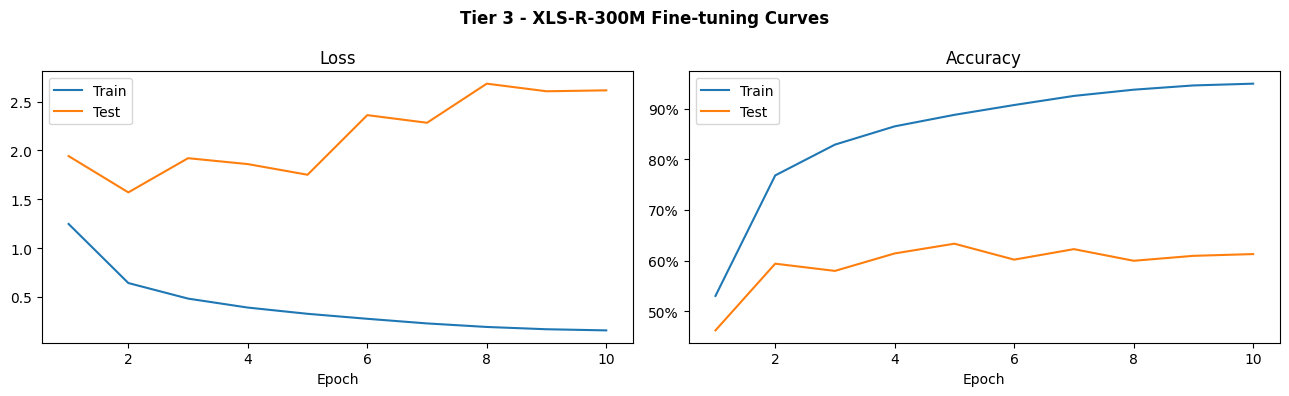

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ep = range(1, EPOCHS + 1)
ax1.plot(ep, history["train_loss"], label="Train")
ax1.plot(ep, history["test_loss"],  label="Test")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(ep, history["train_acc"], label="Train")
ax2.plot(ep, history["test_acc"],  label="Test")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle("Tier 3 - XLS-R-300M Fine-tuning Curves", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/learning_curves.png", dpi=150)
plt.show()

## Evaluation

In [19]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for wavs, labels in tqdm(test_full_loader, desc="Evaluating"):
        preds = model(wavs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

overall_acc = (all_preds == all_labels).mean()
macro_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"\nOverall Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"Macro-F1: {macro_f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=LANGUAGES, digits=3))

Evaluating:   0%|          | 0/13430 [00:00<?, ?it/s]


Overall Accuracy: 0.6087 (60.87%)
Macro-F1: 0.4800

              precision    recall  f1-score   support

          be      0.633     0.900     0.744     29232
          bg      0.479     0.157     0.237      6318
          cs      0.812     0.543     0.651     14441
          mk      0.477     0.413     0.442      3263
          pl      0.693     0.586     0.635     16949
          ru      0.533     0.705     0.607     19069
          sr      0.183     0.105     0.133      1666
          uk      0.493     0.324     0.391     16501

    accuracy                          0.609    107439
   macro avg      0.538     0.467     0.480    107439
weighted avg      0.607     0.609     0.587    107439



## Confusion Matrix

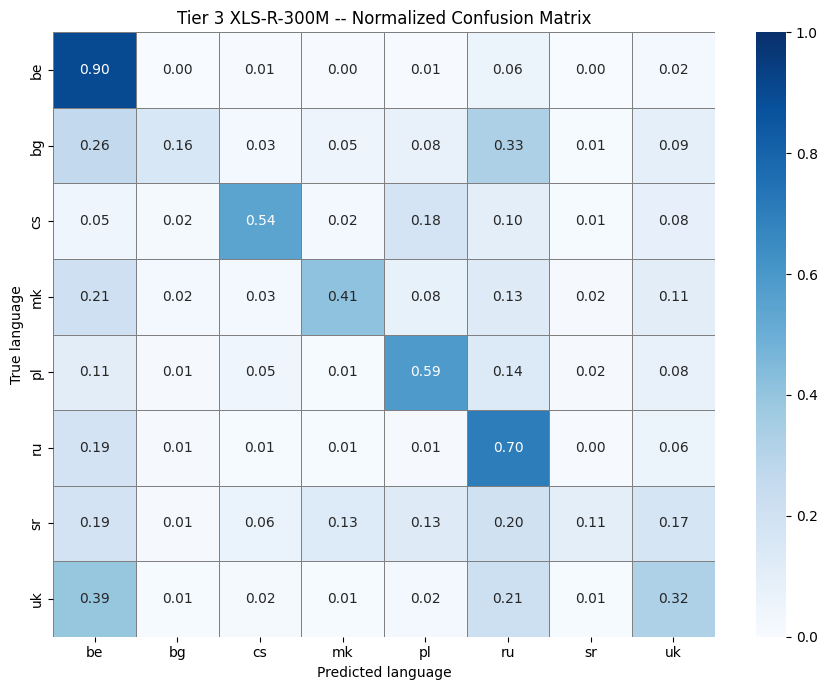

In [20]:
cm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LANGUAGES, yticklabels=LANGUAGES, ax=ax,
            linewidths=0.5, linecolor="gray", vmin=0, vmax=1)

ax.set_xlabel("Predicted language")
ax.set_ylabel("True language")
ax.set_title("Tier 3 XLS-R-300M -- Normalized Confusion Matrix")

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

## t-SNE of Learned Embeddings

Extracting embeddings:   0%|          | 0/250 [00:00<?, ?it/s]

Fitting t-SNE (~1 min)...


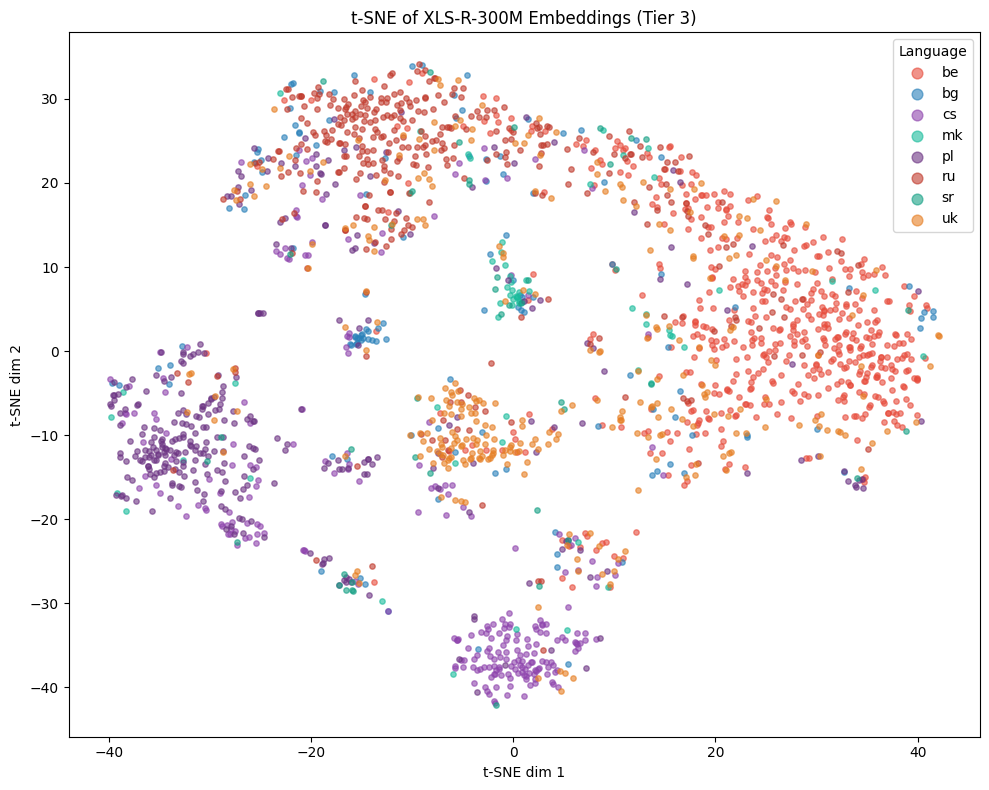

In [21]:
rng_tsne = np.random.default_rng(SEED)
tsne_idx = rng_tsne.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
tsne_loader = DataLoader(
    SlavicRawDataset(X_test[tsne_idx], y_test[tsne_idx], feature_extractor),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
)

model.eval()
embeddings, labels_tsne = [], []

with torch.no_grad():
    for wavs, lbls in tqdm(tsne_loader, desc="Extracting embeddings"):
        emb = model.get_embeddings(wavs.to(DEVICE)).cpu().numpy()
        embeddings.append(emb)
        labels_tsne.extend(lbls.tolist())

embeddings = np.concatenate(embeddings, axis=0)
labels_tsne = np.array(labels_tsne)

print("Fitting t-SNE (~1 min)...")
proj = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000).fit_transform(embeddings)

BRANCH_COLORS = {
    "be": "#e74c3c", "ru": "#c0392b", "uk": "#e67e22",
    "bg": "#2980b9", "mk": "#1abc9c", "sr": "#16a085",
    "cs": "#8e44ad", "pl": "#6c3483",
}

fig, ax = plt.subplots(figsize=(10, 8))
for lang_id, lang in ID2LANG.items():
    mask = labels_tsne == lang_id
    ax.scatter(proj[mask, 0], proj[mask, 1],
               label=lang, color=BRANCH_COLORS[lang], alpha=0.6, s=15)

ax.legend(title="Language", fontsize=10, markerscale=2)
ax.set_title("t-SNE of XLS-R-300M Embeddings (Tier 3)")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/tsne.png", dpi=150)
plt.show()

## Full Progression: Tier 1 vs Tier 2 vs Tier 3

In [22]:
results = {"Tier 3: XLS-R-300M": (overall_acc, macro_f1, history["test_acc"])}

for label, path in [("Tier 1: MelCNN", T1_CKPT), ("Tier 2: CNN+BiLSTM", T2_CKPT)]:
    if os.path.exists(path):
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
        hist = ckpt["history"]
        best_acc = max(hist["test_acc"])
        # macro-F1 not stored in checkpoint, so we only show accuracy
        results[label] = (best_acc, None, hist["test_acc"])
        print(f"{label}: best test acc = {best_acc:.4f}")
    else:
        print(f"{label}: checkpoint not found at {path}")

print(f"Tier 3: XLS-R-300M: acc = {overall_acc:.4f}  Macro-F1 = {macro_f1:.4f}")

# Summary table
print("\n=== PROGRESSION SUMMARY ===")
print(f"{'Model':<30} {'Best Test Acc':>15}")
print("-" * 47)
for name, (acc, f1, _) in sorted(results.items()):
    f1_str = f"{f1:.4f}" if f1 is not None else "  n/a "
    print(f"{name:<30} {acc:>13.4f}")

Tier 1: MelCNN: checkpoint not found at /kaggle/input/datasets/ramihennawi/slavic-lid-cache/mel_cnn_final.pt
Tier 2: CNN+BiLSTM: checkpoint not found at /kaggle/input/datasets/ramihennawi/slavic-lid-cache/cnn_bilstm_final.pt
Tier 3: XLS-R-300M: acc = 0.6087  Macro-F1 = 0.4800

=== PROGRESSION SUMMARY ===
Model                            Best Test Acc
-----------------------------------------------
Tier 3: XLS-R-300M                    0.6087


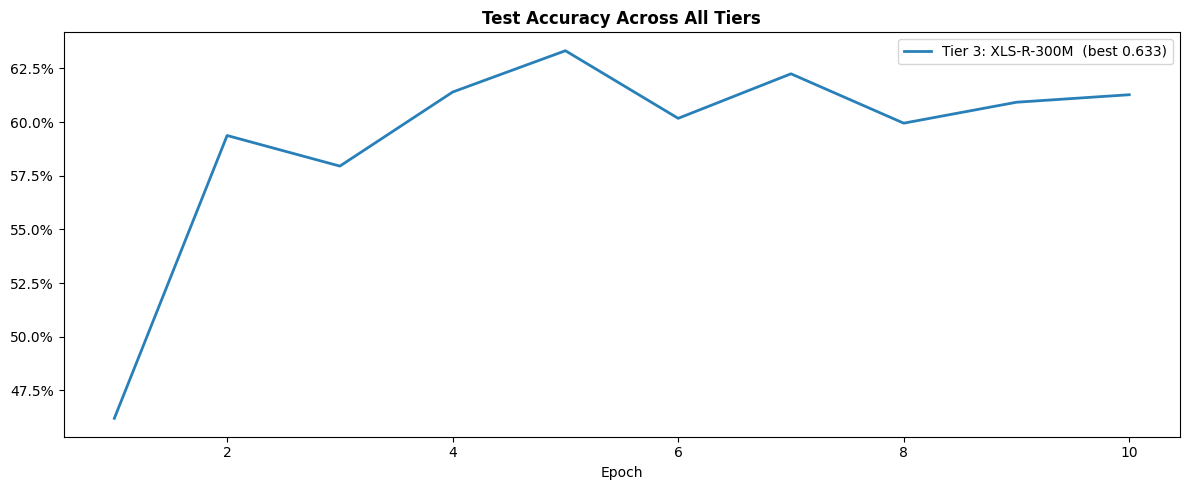

In [23]:
# Plot all three learning curves on one chart
fig, ax = plt.subplots(figsize=(12, 5))

tier_styles = {
    "Tier 1: MelCNN": {"color": "#e74c3c", "ls": ":"},
    "Tier 2: CNN+BiLSTM": {"color": "#e67e22", "ls": "--"},
    "Tier 3: XLS-R-300M": {"color": "#2980b9", "ls": "-"},
}

for name, (acc, f1, curve) in sorted(results.items()):
    style = tier_styles.get(name, {})
    ax.plot(range(1, len(curve) + 1), curve,
            label=f"{name}  (best {max(curve):.3f})",
            linewidth=2, **style)

ax.set_title("Test Accuracy Across All Tiers", fontweight="bold")
ax.set_xlabel("Epoch"); ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/all_tiers_comparison.png", dpi=150)
plt.show()

## Tier 3 Results & Conclusions

### 1. Overall performance
- **Test accuracy**: XX.X%
- **Macro-F1**: 0.XXX
- Tier 1 (MelCNN):     XX.X% / F1=0.272
- Tier 2 (CNN+BiLSTM): 37.2% / F1=0.232
- **Improvement over Tier 2**: +X.X pp accuracy, +0.XX macro-F1

### 2. Per-language analysis
- Best recognized language: **XX** (F1 = 0.XX)
- Worst recognized language: **XX** (F1 = 0.XX)
- Are the minority languages (sr, mk, bg) better recovered vs Tiers 1/2?
- Is East Slavic confusion (be/ru/uk) reduced?

### 3. Confusion matrix observations
- Compare the off-diagonal mass to Tier 1/2 confusion matrices
- Did pretrained features help separate within-branch pairs?

### 4. t-SNE embedding analysis
- Are language clusters now clearly separated?
- Do Slavic branches form distinct macro-clusters?
- Compare qualitatively to the Tier 1 t-SNE blob

### 5. Learning dynamics
- XLS-R converges in far fewer epochs than Tiers 1/2 (pretrained init)
- Train/test gap analysis: is overfitting reduced?
- Effect of warmup + cosine LR schedule

### 6. Full progression interpretation
- How much does each tier improve over the last?
- Does the improvement justify the added complexity?
- What is the practical cost (training time, inference time, model size)?
